In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os #to look in to the files we have in our server
import cv2

from PIL import Image

from tensorflow import keras
import tensorflow.keras.layers as k

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

In [9]:
os.environ['KERAS_BACKEND'] = 'tensorflow'   #the backend we are using is tenserflow
np.random.seed()   #it will make sure my results are reproducible

In [10]:
import os
#/kaggle/input/cell-images-for-detecting-malaria (this is the path)
print(os.listdir("/kaggle/input/cell-images-for-detecting-malaria/"))
# Output should include: ['cell_images']


['cell_images']


In [11]:
image_dir = "/kaggle/input/cell-images-for-detecting-malaria/cell_images"
size = 64
dataset = []
label = []

*os.listdir - It will Give all the images one by one and the return type is list*

In [12]:
parasitized_img = os.listdir(image_dir + "/Parasitized")

In [11]:
len(parasitized_img)

13780

In [12]:
parasitized_img[0]

'C99P60ThinF_IMG_20150918_141001_cell_93.png'

In [13]:
'C99P60ThinF_IMG_20150918_141001_cell_93.png'.split('.')

['C99P60ThinF_IMG_20150918_141001_cell_93', 'png']

In [14]:
'C99P60ThinF_IMG_20150918_141001_cell_93.png'.split('.')[1]

'png'

>  It reads the Image In the form of Array by using cv2

In [13]:
cv2.imread("/kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized/C99P60ThinF_IMG_20150918_141001_cell_93.png")

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [16]:
list1 = ['Deep','Neural','Network']
for i,name in enumerate(list1):
    print(f"Index {i} {name}")

Index 0 Deep
Index 1 Neural
Index 2 Network


In [17]:
for i,image_name in enumerate(parasitized_img):
    if(image_name.split('.')[1]=='png'): #cuz some anomlies may be present so checking if its png
        image = cv2.imread(image_dir+'/Parasitized/'+image_name)
    

> Now we want to resize our image , and to resize our image we need PIL library , and to use this we need to convert image to image array format
> Here RGB = (a channel)
> 
> from PIL import Image

In [18]:
for i,image_name in enumerate(parasitized_img):
    if(image_name.split('.')[1]=='png'): 
        image = cv2.imread(image_dir+'/Parasitized/'+image_name)
        image = Image.fromarray(image,'RGB')
        image = image.resize((size,size))   #resizing to 64X64  original random like 192X180

        dataset.append(np.array(image))  #we need to convert back image array to numpy array
        label.append(0)  #adding classification label 0 for parasitized

In [19]:
uninfected_img = os.listdir(image_dir+"/Uninfected")
for i,image_name in enumerate(uninfected_img):
    if image_name.split('.')[-1] == 'png':  # safer with [-1] in case of multiple dots
        image_path = os.path.join(image_dir, 'Uninfected', image_name)
        image = cv2.imread(image_path)
        image = Image.fromarray(image,'RGB')
        image = image.resize((size,size))   #resizing to 64X64  original random like 192X180

        dataset.append(np.array(image))  #we need to convert back image array to numpy array
        label.append(1)  #adding classification label 1 for uninfected

KeyboardInterrupt: 

In [ ]:
len(uninfected_img)


1. > Both uninfected and parasitized are of equal size
   >  if its not balanced there is another method called data Augmentation
   >  By this method we can create more image of the class which lacking in the number to make our dataset balanced


* As there are lot of images we posibly take a lot of time to end the completion process so we are taking 3000 rows for our data now
  

In [14]:
from tqdm.notebook import tqdm #it shows the progress for libraries

In [15]:
parasitized_img = parasitized_img[:3000]
for i,image_name in enumerate(tqdm(parasitized_img)):
    if(image_name.split('.')[1]=='png'): 
        image = cv2.imread(image_dir+'/Parasitized/'+image_name)
        image = Image.fromarray(image,'RGB')
        image = image.resize((size,size))   #resizing to 64X64  original random like 192X180

        dataset.append(np.array(image))  #we need to convert back image array to numpy array
        label.append(0)  #adding classification label 0 for parasitized

  0%|          | 0/3000 [00:00<?, ?it/s]

In [16]:
uninfected_img = os.listdir(image_dir+"/Uninfected")
uninfected_img = uninfected_img[:3000]
for i,image_name in enumerate(tqdm(uninfected_img)):
    if image_name.split('.')[-1] == 'png':  # safer with [-1] in case of multiple dots
        image_path = os.path.join(image_dir, 'Uninfected', image_name)
        image = cv2.imread(image_path)
        image = Image.fromarray(image,'RGB')
        image = image.resize((size,size))   #resizing to 64X64  original random like 192X180

        dataset.append(np.array(image))  #we need to convert back image array to numpy array
        label.append(1)  #adding classification label 1 for uninfected

  0%|          | 0/3000 [00:00<?, ?it/s]

## Split the data in to train and test

In [17]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

In [18]:
xtrain, xtest, ytrain, ytest = train_test_split(dataset, to_categorical(np.array(label)), test_size=0.2, random_state=0)
#random_state = 0 means every time we do it its reproducible

>Why to_categorical(...)?
Most deep learning models (especially with softmax activation in the output layer) expect the labels to be in one-hot encoded format.
>If you're using categorical_crossentropy as your loss function
>And you have more than 1 output neuron (e.g., 2 for binary classification in softmax style)
>Then your ytrain and ytest need to be categorical vectors, not scalar labels.

# CNN Model Architecture

In [19]:
INPUT_SHAPE = (size,size,3)
type(INPUT_SHAPE)
#import tensorflow.keras.layers as k

tuple

In [20]:
inp = k.Input(shape = INPUT_SHAPE)          #image input is of 64X64 that we have created
conv1 = k.Conv2D(32,kernel_size = (3,3),activation = 'relu',padding = "same")(inp)
pool1 = k.MaxPool2D(pool_size = (2,2))(conv1)
norm1 = k.BatchNormalization(axis=-1)(pool1)
drop1 = k.Dropout(rate=0.2)(norm1)

conv2 = k.Conv2D(32,kernel_size = (3,3),activation = 'relu',padding = 'same')(drop1)
pool2 = k.MaxPool2D(pool_size = (2,2))(conv2)
norm2 = k.BatchNormalization(axis=-1)(pool2)
drop2 = k.Dropout(rate = 0.2)(norm2)

#Now flattening it
flat = k.Flatten()(drop2)

hidden1 = k.Dense(512 ,activation = 'relu')(flat)
norm3 = k.BatchNormalization(axis=-1)(hidden1)
drop3 = k.Dropout(rate = 0.2)(norm3)

hidden2 = k.Dense(256 ,activation = 'relu')(flat)
norm4 = k.BatchNormalization(axis=-1)(hidden2)
drop4 = k.Dropout(rate = 0.2)(norm4)

out = k.Dense(2,activation = 'sigmoid')(drop4)

* conv2D(no of filters,the filter dim we move around image, activation function ,
* if we do filtering the image size reduce and we left with -2
* Why we use batch normalization - cuz we want uniformality in our dataset
* Dropout - By default we miss our some data so model need to rethink about data
* Here we are dropping 20% about the features
* Hidden1 - here we are passing 512 features after flattening it
* k.Dense(2 for parasitized and uninfected and as its binary classification we are using sigmoid)
* 

In [21]:
model = keras.Model(inputs = inp,outputs = out)
model.compile(optimizer='adam',metrics=['accuracy'],
              loss="categorical_crossentropy")

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,109,346 (8.05 MB)

 Trainable params: 2,108,706 (8.04 MB)

 Non-trainable params: 640 (2.50 KB)

None


* Adam optimizer (a second order gradient descent) alternate for gradient descent
* also adam converts much faster
* matrix = accuracy for evaluation

* Passing image 64X64X3
* Then Convulation with 32 features
* Max pooling we are using 2X2 to find out best minimal feature so it became half
* Batch NOrmalization - change the values
* The conv2 pass 32X32 image
* Then in the flatten 8192 features passes i.2. 16X16X32
* Then passed a neuron with 512 layers then 256 layers
* Now we are having weights and biases in the model
* There are a lot of parameters that require training 

In [22]:
history = model.fit(np.array(xtrain),ytrain,
                   batch_size = 64,verbose=1,epochs=5,validation_split =0.1,
                   shuffle=False)

Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 226ms/step - accuracy: 0.6179 - loss: 0.9478 - val_accuracy: 0.6458 - val_loss: 0.8441
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - accuracy: 0.7260 - loss: 0.5639 - val_accuracy: 0.6438 - val_loss: 0.7562
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step - accuracy: 0.8093 - loss: 0.4318 - val_accuracy: 0.5646 - val_loss: 2.2658
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 230ms/step - accuracy: 0.8733 - loss: 0.3024 - val_accuracy: 0.7542 - val_loss: 0.7219
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.9020 - loss: 0.2315 - val_accuracy: 0.6458 - val_loss: 2.4322


* verbose = inbuilt keras , how i want to see the iteration
* valid_split = it take 10% of training data for validation
  

In [ ]:
xtrain

In [23]:
print("test_accuracy: {:.2f}%".format(model.evaluate(np.array(xtest), np.array(ytest))[1] * 100))

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6593 - loss: 2.3545
test_accuracy: 66.08%


In [24]:
import matplotlib.pyplot as plt

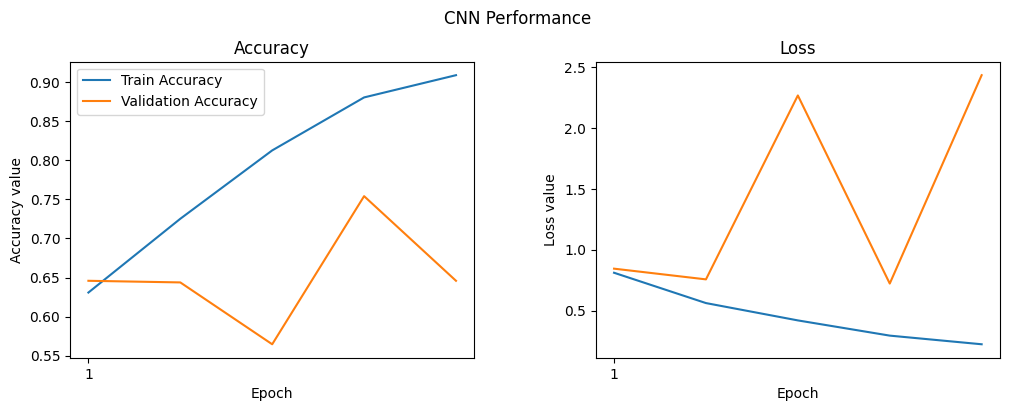

In [27]:
f , (ax1,ax2)  = plt.subplots(1,2,figsize=(12,4))
t = f.suptitle('CNN Performance ', fontsize = 12)
f.subplots_adjust(top=0.85,wspace=0.3)

max_epoch = len(history.history['accuracy'])+1
epoch_list = list(range(1,max_epoch))
ax1.plot(epoch_list,history.history['accuracy'],label = 'Train Accuracy')
ax1.plot(epoch_list,history.history['val_accuracy'],label = 'Validation Accuracy')
ax1.set_xticks(np.arange(1,max_epoch,5))
ax1.set_ylabel('Accuracy value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
l1 = ax1.legend(loc="best")

ax2.plot(epoch_list,history.history['loss'],label = 'Train Loss')
ax2.plot(epoch_list,history.history['val_loss'],label = 'Validation Loss')
ax2.set_xticks(np.arange(1,max_epoch,5))
ax2.set_ylabel('Loss value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
l2 = ax1.legend(loc="best")